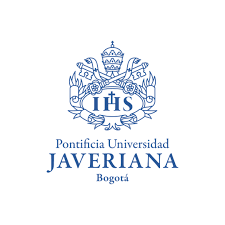
# **Procesamiento de Alto Volumen de Datos**

### Laboratorio: **Clasificación de datos con métricas de rendimiento**

Autor: Daniel Felipe Castro Moreno

Fecha de Inicio: 28/04/2026

Fecha actual: 28/04/2026

## **Objetivo**

*

## **Metodología**

1. 
2. 
3. 
4. 
5. 

In [1]:
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Importat bibliotecas generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas especializadas
from pylab import *
import findspark
findspark.init('/Almacen/Spark') 
from pyspark.sql import functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext, SparkSession, Row
from pyspark.sql.types import *

from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from sklearn.metrics import roc_curve, auc

In [3]:
configura = SparkConf() #---> Prepara los ajustes del programa
configura.setAppName("Classification_Castro") #---> Nombre del proyecto
sparkCastro = SparkSession.builder.config(conf=configura).getOrCreate() #---> Crear la sesión de Spark
SQLContext(sparkContext=sparkCastro.sparkContext, sparkSession=sparkCastro) #---> Habilita el uso de tablas y lenguaje SQL
sparkContextoCastro = sparkCastro.sparkContext.getOrCreate() #---> Conecta el contexto
print("Sesion creada: sparkCastro")
sparkCastro

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 08:44:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/28 08:44:58 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Sesion creada: sparkCastro


In [4]:
# Creación del dataframe
dfPy00 = sparkCastro.read.format("csv").option("header","true").option("sep", ";").load("bank-full.csv")
dfPy00.show(5)

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

### Comentarios
- Todos los datos se encuentran en tipo String
- Se identifica el cambio de entero a double
- La última columna tiene únicamente valores negativos

In [5]:
# Cantidad de datos
print(f"Se tiene un total de {dfPy00.count()} registros")

Se tiene un total de 45211 registros


In [6]:
dfPy00.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [9]:
# Las siguientes columnas se cambian a entero
colInt = ['age', 'balance', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous']
dfPy01 = dfPy00
for column in colInt:
    dfPy01 = dfPy01.withColumn(column, F.col(column).cast("integer"))
dfPy01.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [8]:
# Se revisa el balance del dataset. La idea es conocer si hay posibilidades de Sesgo
total = dfPy01.count()
df_Y = dfPy01.groupBy("y").count()
auxPD = df_Y.withColumn("Porcentaje", df_Y["count"]*100/total)
auxPD.show()

+---+-----+------------------+
|  y|count|        Porcentaje|
+---+-----+------------------+
| no|39922| 88.30151954170445|
|yes| 5289|11.698480458295547|
+---+-----+------------------+



### Comentarios
Al revisar el balanceo sobre las etiquetas o la columna target, se observa:
- La clase minoritaria es "yes" con ~11.7% y representa 5289 registros
- La clase mayoritaria es "no" con ~88.3% y representa 39922 registros
La variable es binaria y es importante tener en cuenta no hacer sesgo al tratar los modelos para hacer predicción
Se recomienda revisar ...

In [ ]:
# Se revisa de fpr,a exhaustiva las estadísticas del dataset
dfPy01 

### Comentarios
Se observa las estadísticas de los valores nominales
Se puede observar min edad ..., max .., 

In [10]:
dfPy01.describe().toPandas()

26/04/28 08:53:32 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,0,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,None,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,None,4918,63,871,275,unknown,yes
